# TD3 : Analyse et visualisation des donnees nettoyees
## Dataset : Palmer Penguins (sortie du pipeline de nettoyage, TD2)

**Contexte :** le nettoyage du TD2 a produit `penguins_cleaned.csv`. Avant de passer a la modelisation (TD 02, apprentissage supervise), on explore ce dataset propre en profondeur : resumer les distributions, relier les variables entre elles, decider quelles variables comptent, et anticiper ce qu'un modele pourra apprendre.

**Datamap (dictionnaire des données) :**

| Colonne | Type | Description |
|---|---|---|
| `species` | catégorielle | Espèce du manchot : `Adelie`, `Chinstrap` ou `Gentoo` |
| `island` | catégorielle | Île de l'archipel Palmer où l'individu a été observé |
| `bill_length_mm` | numérique (mm) | Longueur du bec |
| `bill_depth_mm` | numérique (mm) | Profondeur (hauteur) du bec |
| `flipper_length_mm` | numérique (mm) | Longueur des nageoires |
| `body_mass_g` | numérique (g) | Masse corporelle |
| `sex` | catégorielle | Sexe de l'individu : `Male` ou `Female` |

Cette demarche suit le canevas du cours *Analyse & visualisation* : une bonne visualisation sert a **resumer**, **relier**, **decider** et **anticiper** - jamais a decorer.

---
## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.max_columns', None)

---
## 1. Chargement des donnees nettoyees

On charge la sortie du TD2. Si le fichier n'existe pas encore (TD2 pas encore execute), on retombe sur `penguins_clean.csv` pour pouvoir quand meme suivre ce notebook.

In [2]:
try:
    df = pd.read_csv('penguins_cleaned.csv')
    source = 'penguins_cleaned.csv (sortie du TD2)'
except FileNotFoundError:
    print("penguins_cleaned.csv introuvable : execute d'abord tp_dataprep_2_sale.ipynb (section 10) pour le generer.")
    df = pd.read_csv('penguins_clean.csv')
    source = 'penguins_clean.csv (secours)'

print(f"Source     : {source}")
print(f"Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes")
df.head()

Source     : penguins_cleaned.csv (sortie du TD2)
Dimensions : 340 lignes x 7 colonnes


,species,island,sex,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,Gentoo,Biscoe,Female,42.9,13.1,215.0,5000.0
1,Adelie,Dream,Female,37.3,17.8,191.0,3350.0
2,Chinstrap,Dream,Male,50.8,19.0,210.0,4100.0
3,Adelie,Biscoe,Female,36.4,17.1,184.0,2850.0
4,Adelie,Torgersen,Male,45.8,18.9,197.0,4150.0


In [3]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("=== Le nettoyage a-t-il fonctionne ? ===")
print(f"Valeurs manquantes      : {df.isnull().sum().sum()}")
print(f"Doublons                : {df.duplicated().sum()}")
print(f"Variables numeriques    ({len(num_cols)}) : {num_cols}")
print(f"Variables categorielles ({len(cat_cols)}) : {cat_cols}")

=== Le nettoyage a-t-il fonctionne ? ===
Valeurs manquantes      : 0
Doublons                : 0
Variables numeriques    (4) : ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Variables categorielles (3) : ['species', 'island', 'sex']


---
## 2. Quel graphique pour quelle variable ?

Avant de tracer quoi que ce soit, on choisit le bon type de graphique selon les variables en jeu :

| Variables | Graphique | Ce qu'il montre |
|---|---|---|
| 1 numerique | Histogramme | La distribution (forme, centre, dispersion) |
| 1 numerique x 1 categorielle | Boxplot | La distribution par groupe |
| 2 numeriques | Scatter (nuage de points) | La relation entre les deux variables |
| 1 categorielle | Barplot / countplot | Les effectifs par categorie |
| 2 categorielles | Heatmap de contingence | L'association entre categories |

Regle d'or : *si un graphique demande une longue explication, il a sans doute echoue.*

---
## 3. Resumer : distributions univariees

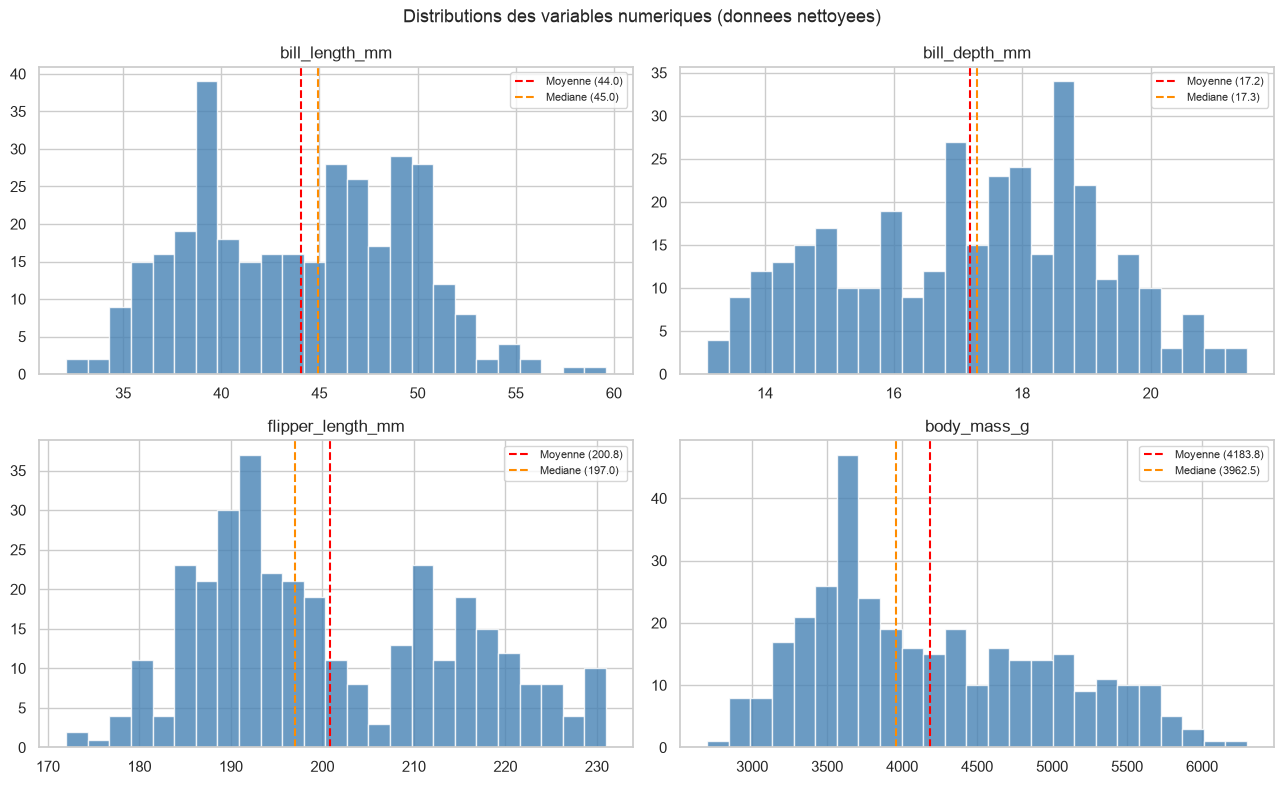

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.flat, num_cols):
    ax.hist(df[col], bins=25, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Moyenne ({df[col].mean():.1f})')
    ax.axvline(df[col].median(), color='darkorange', linestyle='--', label=f'Mediane ({df[col].median():.1f})')
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle('Distributions des variables numeriques (donnees nettoyees)', fontsize=13)
plt.tight_layout()
plt.show()

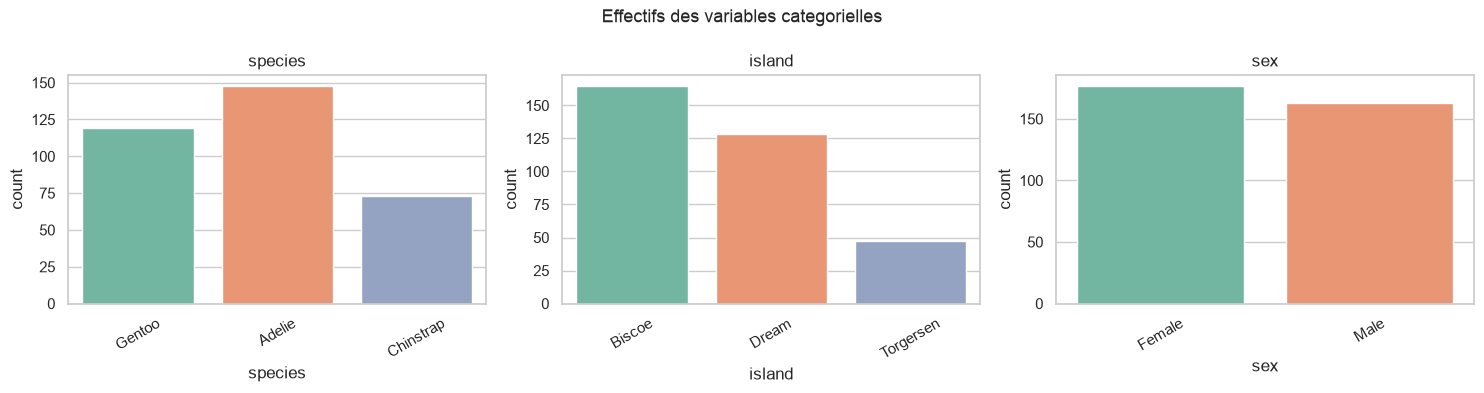

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, x=col, ax=ax, hue=col, legend=False)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Effectifs des variables categorielles', fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Relier : relations bivariees

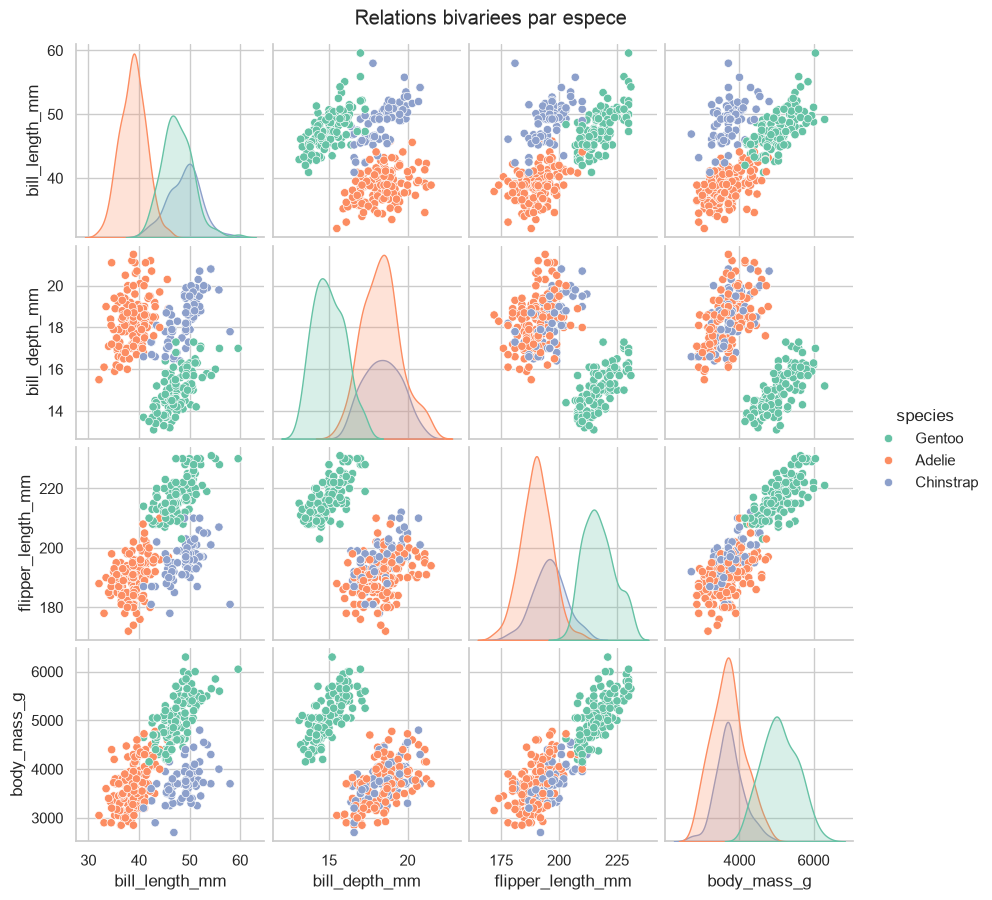

In [6]:
sns.pairplot(df, vars=num_cols, hue='species', diag_kind='kde', height=2.2)
plt.suptitle('Relations bivariees par espece', y=1.02)
plt.show()

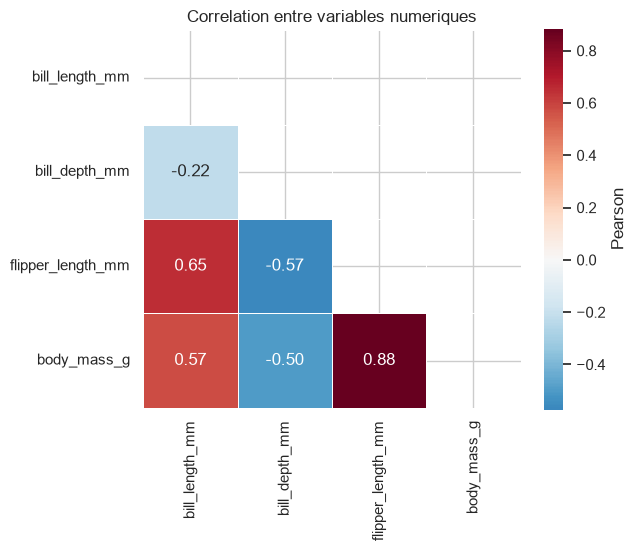

In [7]:
corr = df[num_cols].corr(method='pearson')

plt.figure(figsize=(6.5, 5.5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, linewidths=0.5, square=True, cbar_kws={'label': 'Pearson'})
plt.title('Correlation entre variables numeriques')
plt.tight_layout()
plt.show()

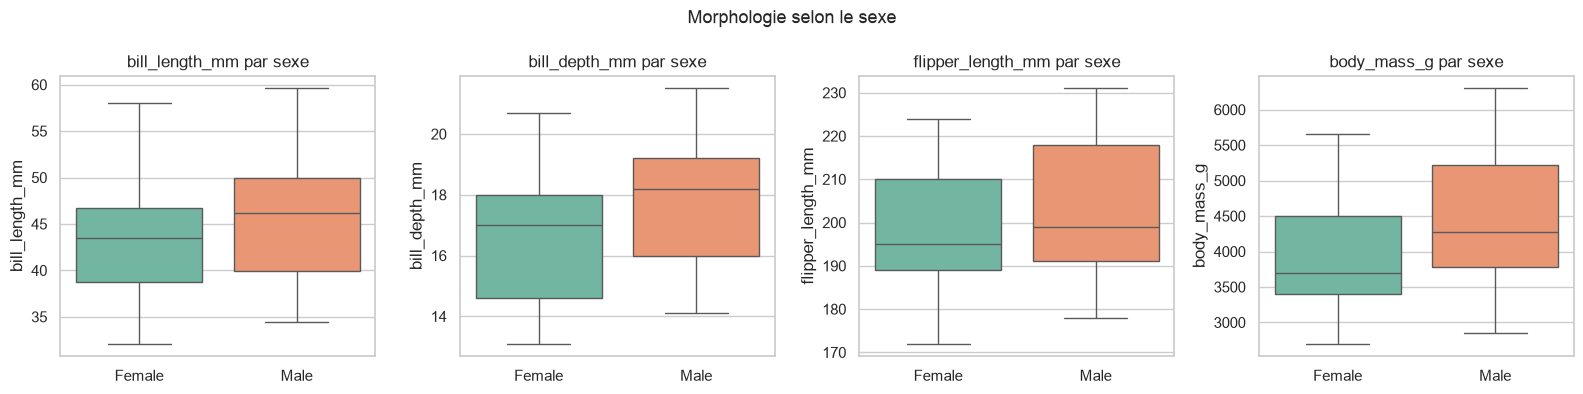

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x='sex', y=col, ax=ax, hue='sex', legend=False)
    ax.set_title(f'{col} par sexe')
    ax.set_xlabel('')
plt.suptitle('Morphologie selon le sexe', fontsize=13)
plt.tight_layout()
plt.show()

### 4.1 V de Cramer : toutes les paires categorielles

Le TD1 calculait le V de Cramer pour une seule paire. Ici on calcule la matrice complete pour reperer en un coup d'oeil quelles variables categorielles sont associees.

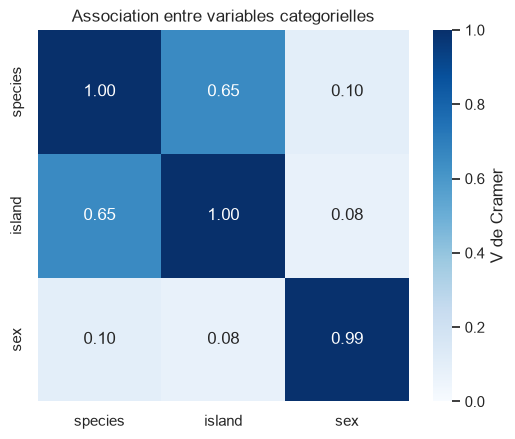

In [9]:
def cramers_v(x, y):
    """Calcule le V de Cramer entre deux series categorielles."""
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

cramers_matrix = pd.DataFrame(
    [[cramers_v(df[c1], df[c2]) for c2 in cat_cols] for c1 in cat_cols],
    index=cat_cols, columns=cat_cols,
)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cramers_matrix, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            square=True, cbar_kws={'label': 'V de Cramer'})
plt.title('Association entre variables categorielles')
plt.tight_layout()
plt.show()

---
## 5. Decider : quelles variables separent le mieux les especes ?

Pour preparer le TD 02 (classification), on cherche quelles variables numeriques discriminent le plus les especes. Le rapport de correlation eta² mesure la part de variance d'une variable numerique expliquee par une categorielle : plus il est proche de 1, plus la variable separe bien les groupes.

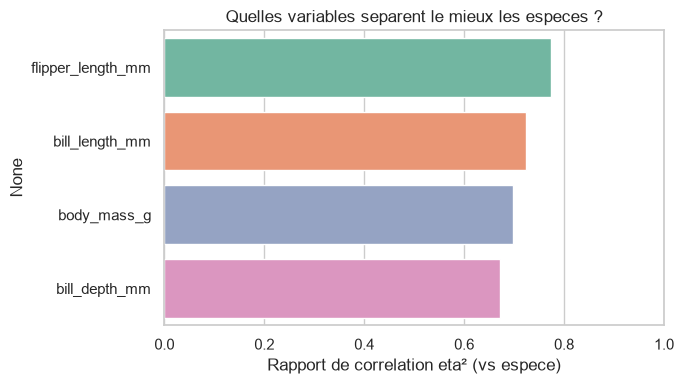

flipper_length_mm    0.775
bill_length_mm       0.725
body_mass_g          0.698
bill_depth_mm        0.672
dtype: float64


In [10]:
def correlation_ratio(categories, values):
    """Rapport de correlation eta² entre une categorielle et une numerique."""
    cats = pd.Categorical(categories)
    ss_total = ((values - values.mean()) ** 2).sum()
    ss_between = 0
    for cat in cats.categories:
        group = values[categories == cat]
        ss_between += len(group) * (group.mean() - values.mean()) ** 2
    return ss_between / ss_total

eta2 = pd.Series({col: correlation_ratio(df['species'], df[col]) for col in num_cols}).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=eta2.values, y=eta2.index, hue=eta2.index, palette='Set2', legend=False)
plt.xlabel("Rapport de correlation eta² (vs espece)")
plt.title("Quelles variables separent le mieux les especes ?")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

print(eta2.round(3))

---
## 6. Anticiper : a quoi ressemblera la separation ?

On trace les deux variables les plus discriminantes (d'apres le classement ci-dessus) l'une contre l'autre. Si les especes forment des groupes bien separes visuellement, un modele de classification simple (TD 02) devrait bien fonctionner.

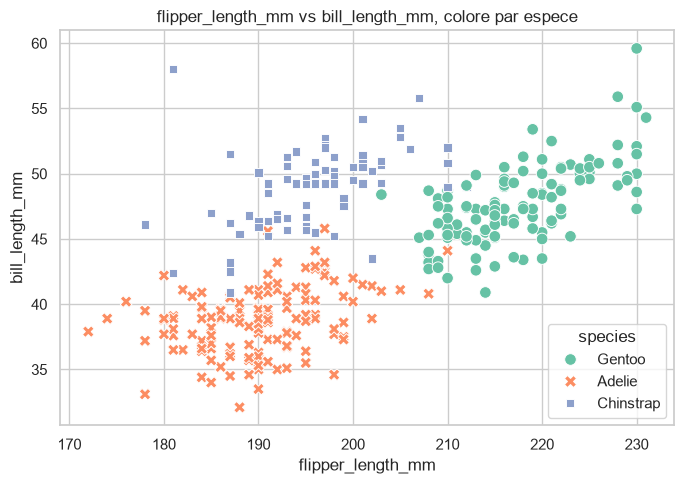

In [11]:
top2 = eta2.index[:2].tolist()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x=top2[0], y=top2[1], hue='species', style='species', s=70)
plt.title(f'{top2[0]} vs {top2[1]}, colore par espece')
plt.tight_layout()
plt.show()

---
## 7. Bonnes pratiques : une viz utile, pas decorative

Un graphique qui empile trop d'information (couleur + forme + taille + facette) devient illisible. Comparaison :

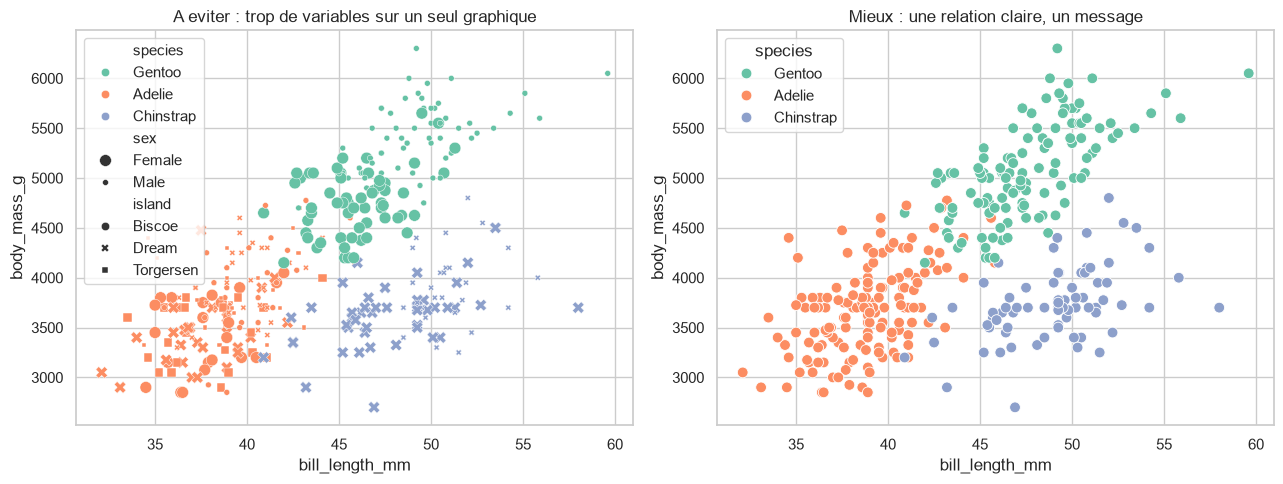

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# A eviter : trop de dimensions encodees a la fois
sns.scatterplot(data=df, x='bill_length_mm', y='body_mass_g', hue='species',
                 style='island', size='sex', ax=axes[0], legend='brief')
axes[0].set_title("A eviter : trop de variables sur un seul graphique")

# Mieux : une question, un graphique
sns.scatterplot(data=df, x='bill_length_mm', y='body_mass_g', hue='species', s=60, ax=axes[1])
axes[1].set_title("Mieux : une relation claire, un message")

plt.tight_layout()
plt.show()

---
## 8. Synthese

**Demarche d'analyse visuelle (a reproduire sur tout dataset propre) :**
1. **Resumer** : histogrammes et barplots pour chaque variable seule
2. **Relier** : pairplot, correlation de Pearson, V de Cramer, boxplots croises
3. **Decider** : le rapport de correlation eta² identifie les variables les plus informatives
4. **Anticiper** : un scatter des variables les plus discriminantes prefigure la difficulte du probleme de classification

**Ce qu'on retient sur ce dataset :**
- Les variables morphologiques (bec, nageoires, masse) separent bien les trois especes.
- `species` et `island` sont fortement associees : certaines especes ne vivent que sur certaines iles.
- Les distributions sont propres : plus d'aberrations, plus de valeurs manquantes.

**Prochaine etape :** direction le **TD 02 (apprentissage supervise)** pour entrainer un modele de classification sur ces variables.